# Import Libraries


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Datasets


In [43]:
movies = pd.read_csv("tmdb_5000_movies.csv")
credits = pd.read_csv("tmdb_5000_credits.csv")

## View Dataset

In [44]:
movies.head()
credits.head()

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


## Dataset Information and shape

In [45]:
movies.info()
movies.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

(4803, 20)

## Missing Values

In [46]:
movies.isnull().sum()

,0
budget,0
genres,0
homepage,3091
id,0
keywords,0
original_language,0
original_title,0
overview,3
popularity,0
production_companies,0


##  REMOVE UNNECESSARY COLUMNS

In [59]:
movies = movies.drop(['homepage', 'tagline'], axis=1)

## Duplicate Values

In [47]:
movies.duplicated().sum()

np.int64(0)

## Merge Datasets

### merge movies and credits

In [48]:
movies = movies.merge(credits, on='title')

## Data Cleaning

### Remove Missing Values

In [49]:
movies.dropna(inplace=True)

## Visualizations

### Most Common Genres

In [50]:
movies['genres'].value_counts().head(10)

,count
genres,
"[{""id"": 18, ""name"": ""Drama""}]",91
"[{""id"": 35, ""name"": ""Comedy""}]",74
"[{""id"": 18, ""name"": ""Drama""}, {""id"": 10749, ""name"": ""Romance""}]",47
"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 10749, ""name"": ""Romance""}]",38
"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""name"": ""Drama""}]",32
"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""name"": ""Drama""}, {""id"": 10749, ""name"": ""Romance""}]",28
"[{""id"": 27, ""name"": ""Horror""}, {""id"": 53, ""name"": ""Thriller""}]",28
"[{""id"": 18, ""name"": ""Drama""}, {""id"": 53, ""name"": ""Thriller""}]",24
"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 28, ""name"": ""Action""}, {""id"": 53, ""name"": ""Thriller""}]",23


### Plot Movie Count


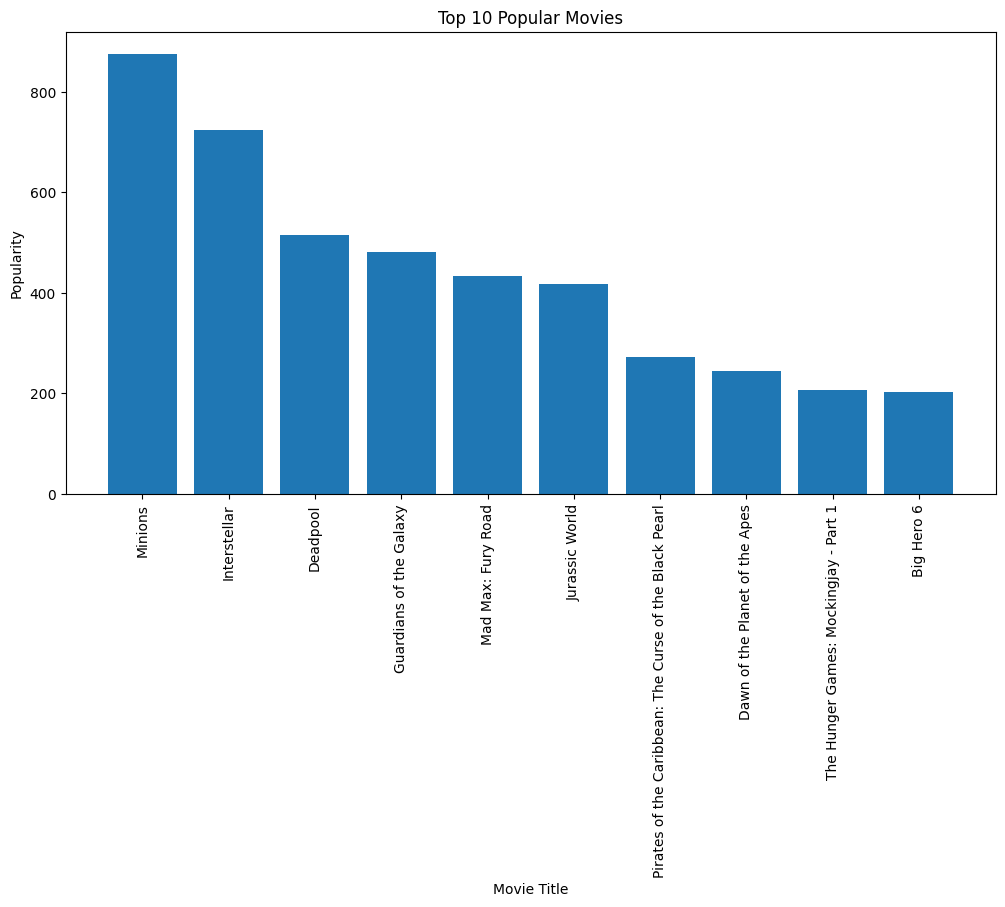

In [56]:
top_movies = movies.sort_values(by='popularity', ascending=False).head(10)

plt.figure(figsize=(12,6))
plt.bar(top_movies['title'], top_movies['popularity'])
plt.xticks(rotation=90)
plt.title("Top 10 Popular Movies")
plt.xlabel("Movie Title")
plt.ylabel("Popularity")
plt.show()

## popular Movie Distribution

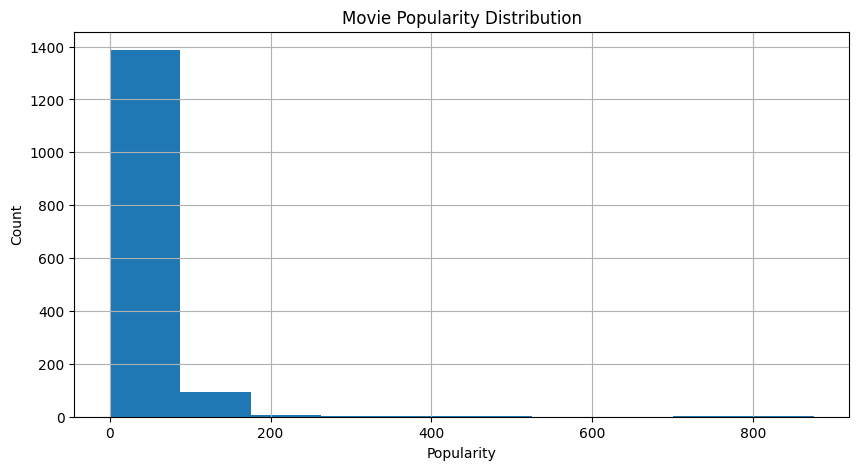

In [55]:
plt.figure(figsize=(10,5))
movies['popularity'].hist()
plt.title("Movie Popularity Distribution")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()

## Vote Average Distribution

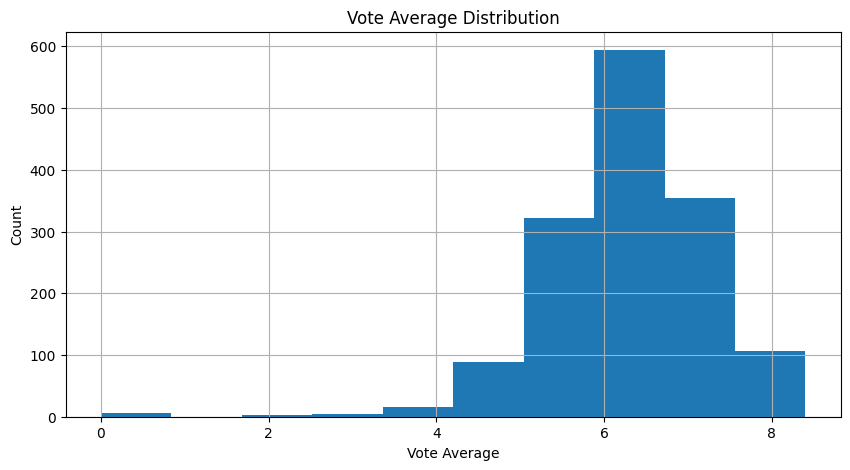

In [54]:
plt.figure(figsize=(10,5))
movies['vote_average'].hist()
plt.title("Vote Average Distribution")
plt.xlabel("Vote Average")
plt.ylabel("Count")
plt.show()

## Release Year Analysis

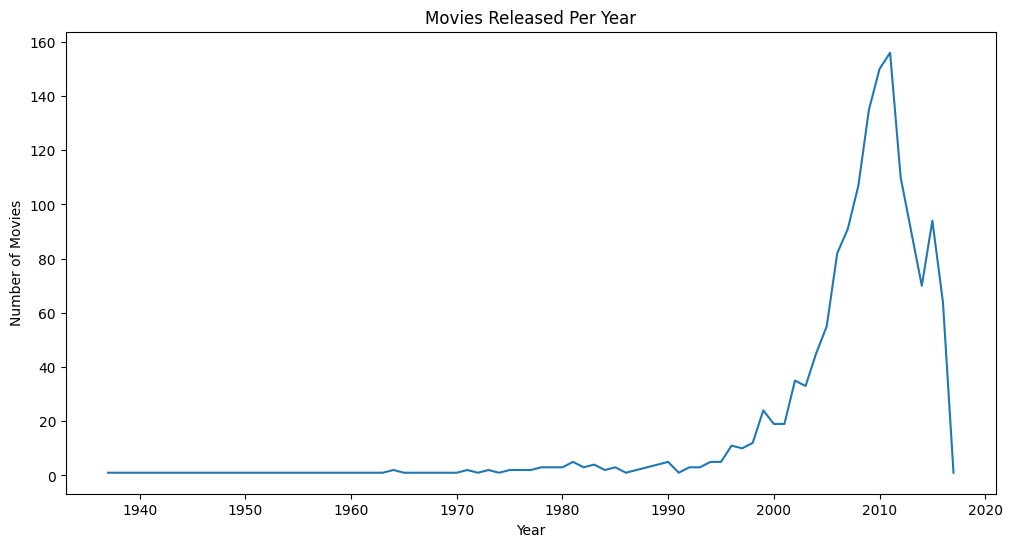

In [57]:
movies['release_date'] = pd.to_datetime(movies['release_date'])

movies['release_year'] = movies['release_date'].dt.year

plt.figure(figsize=(12,6))
movies['release_year'].value_counts().sort_index().plot()
plt.title("Movies Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show()

##  Insights

In [58]:
print("EDA Completed Successfully")

EDA Completed Successfully


# 📊 Insights from EDA

- Dataset contains thousands of movies
- Most movies belong to action and drama genres
- Some columns contain missing values
- Data preprocessing is necessary before recommendation modeling
- Popularity and ratings vary significantly across movies

---

# ✅ Conclusion

EDA helped understand the dataset structure, clean unnecessary data, and prepare the dataset for building the recommendation system using NLP and cosine similarity.